# Cinema Audience Forecasting Challenge: A Business-Driven Approach

## 1. Project Overview & Business Goal

**Goal:** Predict future audience counts for cinema theaters to optimize staffing, inventory, and marketing strategies. Accurate forecasting allows theater managers to make informed decisions, improve operational efficiency, and enhance customer experience. This challenge specifically leverages data from two key booking platforms: **BookNow** (online bookings) and **CinePOS** (point-of-sale systems).

This notebook outlines the entire process from data ingestion and cleaning to feature engineering and predictive modeling, all with a focus on understanding the business implications at each stage.

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


## 2. Setting Up the Environment

We start by importing essential libraries for data manipulation (`pandas`, `numpy`), machine learning (`lightgbm`, `sklearn`), and visualization (`matplotlib`, `seaborn`). We also set up a warnings filter to keep the output clean. These libraries are the foundation for our analytical workflow.

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import os

# Defining the paths
base_path = "/kaggle/input/Cinema_Audience_Forecasting_challenge"

# Loading DataFrames

cinePOS_theaters = pd.read_csv(f"{base_path}/cinePOS_theaters/cinePOS_theaters.csv")
booknow_theaters = pd.read_csv(f"{base_path}/booknow_theaters/booknow_theaters.csv")
relation = pd.read_csv(f"{base_path}/movie_theater_id_relation/movie_theater_id_relation.csv")
cinePOS_booking = pd.read_csv(f"{base_path}/cinePOS_booking/cinePOS_booking.csv")
booknow_booking = pd.read_csv(f"{base_path}/booknow_booking/booknow_booking.csv")
visits = pd.read_csv(f"{base_path}/booknow_visits/booknow_visits.csv")
date_info = pd.read_csv(f"{base_path}/date_info/date_info.csv")
sample_sub = pd.read_csv(f"{base_path}/sample_submission/sample_submission.csv")

# mapping to dfs dictionary
dfs = {
    "cinePOS_theaters": cinePOS_theaters,
    "booknow_theaters": booknow_theaters,
    "relation": relation,
    "cinePOS_booking": cinePOS_booking,
    "booknow_booking": booknow_booking,
    "visits": visits,
    "date_info": date_info,
    "sample_sub": sample_sub
}

# Checking shape, column names, and data types
for name, df in dfs.items():
    print("="*50)
    print(f"Dataset: {name}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("\nInfo:")
    df.info()
    print("\nHead:")
    display(df.head(3))
    print("\n")

Dataset: cinePOS_theaters
Shape: (4690, 5)
Columns: ['cine_theater_id', 'theater_type', 'theater_area', 'latitude', 'longitude']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4690 entries, 0 to 4689
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cine_theater_id  4690 non-null   object 
 1   theater_type     4690 non-null   object 
 2   theater_area     4690 non-null   object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 183.3+ KB

Head:


,cine_theater_id,theater_type,theater_area,latitude,longitude
0,cinePOS_05466,Other,Area_104,22.619233,78.113017
1,cinePOS_08708,Other,Area_104,22.619233,78.113017
2,cinePOS_00753,Other,Area_104,22.619233,78.113017




Dataset: booknow_theaters
Shape: (829, 5)
Columns: ['book_theater_id', 'theater_type', 'theater_area', 'latitude', 'longitude']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   book_theater_id  314 non-null    object 
 1   theater_type     829 non-null    object 
 2   theater_area     829 non-null    object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 32.5+ KB

Head:


,book_theater_id,theater_type,theater_area,latitude,longitude
0,book_00093,Drama,Area_001,22.619233,78.113017
1,book_00078,Drama,Area_001,22.619233,78.113017
2,book_00291,Drama,Area_001,22.619233,78.113017




Dataset: relation
Shape: (150, 2)
Columns: ['book_theater_id', 'cine_theater_id']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   book_theater_id  150 non-null    object
 1   cine_theater_id  150 non-null    object
dtypes: object(2)
memory usage: 2.5+ KB

Head:


...

,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58




Dataset: date_info
Shape: (547, 2)
Columns: ['show_date', 'day_of_week']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547 entries, 0 to 546
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   show_date    547 non-null    object
 1   day_of_week  547 non-null    object
dtypes: object(2)
memory usage: 8.7+ KB

Head:


,show_date,day_of_week
0,2023-01-01,Sunday
1,2023-01-02,Monday
2,2023-01-03,Tuesday




Dataset: sample_sub
Shape: (38062, 2)
Columns: ['ID', 'audience_count']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38062 entries, 0 to 38061
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              38062 non-null  object
 1   audience_count  38062 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 594.8+ KB

Head:


,ID,audience_count
0,book_00001_2024-03-01,0
1,book_00001_2024-03-02,0
2,book_00001_2024-03-03,0


## 3. Data Loading and Initial Exploration

We are provided with several datasets that contain crucial information about theater operations, booking behavior, and historical audience visits. Understanding each dataset's content and structure is the first step to building an effective forecasting model. The data sources are split across two main platforms: BookNow (online) and CinePOS (physical point-of-sale), with a `relation` file linking them.

-   **`cinePOS_theaters.csv`**: Contains metadata (type, area, location) for theaters linked to the CinePOS system.
-   **`booknow_theaters.csv`**: Contains metadata (type, area, location) for theaters linked to the BookNow online platform.
-   **`movie_theater_id_relation.csv`**: This crucial file provides the mapping between `book_theater_id` (from BookNow) and `cine_theater_id` (from CinePOS), allowing us to combine data from both systems effectively.
-   **`cinePOS_booking.csv`**: Detailed transaction-level data for tickets sold via the CinePOS point-of-sale system.
-   **`booknow_booking.csv`**: Detailed transaction-level data for tickets booked through the BookNow online platform. Both booking files are vital for extracting features related to booking trends and lead times.
-   **`booknow_visits.csv`**: Our primary target variable dataset, containing historical `audience_count` for each `book_theater_id` on a specific `show_date`. This is what we aim to predict.
-   **`date_info.csv`**: Supplemental information for each date (e.g., day of week, whether it's a holiday), useful for creating time-based features.
-   **`sample_submission.csv`**: The required format for our final predictions (ID = `book_theater_id` + `show_date`, `audience_count`).

We'll load these into pandas DataFrames and perform an initial check of their shape, columns, and data types to ensure everything is loaded correctly and to identify any immediate issues like missing values or incorrect data types. This initial overview is critical for planning subsequent data cleaning and feature engineering steps.

In [ ]:
# --- Load CSVs ---
base_path = "/kaggle/input/Cinema_Audience_Forecasting_challenge/"

visits = pd.read_csv(base_path + "booknow_visits/booknow_visits.csv", parse_dates=["show_date"])
date_info = pd.read_csv(base_path + "date_info/date_info.csv", parse_dates=["show_date"])
booknow_booking = pd.read_csv(base_path + "booknow_booking/booknow_booking.csv",
                              parse_dates=["show_datetime", "booking_datetime"])
cinePOS_booking = pd.read_csv(base_path + "cinePOS_booking/cinePOS_booking.csv",
                              parse_dates=["show_datetime", "booking_datetime"])
booknow_theaters = pd.read_csv(base_path + "booknow_theaters/booknow_theaters.csv")
cinePOS_theaters = pd.read_csv(base_path + "cinePOS_theaters/cinePOS_theaters.csv")
relation = pd.read_csv(base_path + "movie_theater_id_relation/movie_theater_id_relation.csv")
sample_sub = pd.read_csv(base_path + "sample_submission/sample_submission.csv")

In [ ]:
# Basic overview
print("visits shape:", visits.shape)
print("date_info shape:", date_info.shape)
print("sample_sub shape:", sample_sub.shape)
print("visits date range:", visits['show_date'].min(), "->", visits['show_date'].max())
print("unique train theaters:", visits['book_theater_id'].nunique())

visits shape: (214046, 3)
date_info shape: (547, 2)
sample_sub shape: (38062, 2)
visits date range: 2023-01-01 00:00:00 -> 2024-02-28 00:00:00
unique train theaters: 826


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", font_scale=1.1)


# CONVERTING NECESSARY DATE COLUMNS

dfs["visits"]["show_date"] = pd.to_datetime(dfs["visits"]["show_date"])
dfs["date_info"]["show_date"] = pd.to_datetime(dfs["date_info"]["show_date"])

dfs["booknow_booking"]["show_datetime"] = pd.to_datetime(dfs["booknow_booking"]["show_datetime"])
dfs["booknow_booking"]["booking_datetime"] = pd.to_datetime(dfs["booknow_booking"]["booking_datetime"])

dfs["cinePOS_booking"]["show_datetime"] = pd.to_datetime(dfs["cinePOS_booking"]["show_datetime"])
dfs["cinePOS_booking"]["booking_datetime"] = pd.to_datetime(dfs["cinePOS_booking"]["booking_datetime"])

print("✔ All date fields converted!")

✔ All date fields converted!


### Date Column Conversion

Many of our datasets contain date and time information. For accurate time-series analysis and feature engineering, it's crucial to convert these columns into proper datetime objects. This allows us to extract features like day of the week, month, or year, and to perform time-based aggregations and merges reliably.

eda

## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is key to understanding the underlying patterns, distributions, and relationships within our data. From a business perspective, EDA helps us answer critical questions like:

*   Are overall movie visits trending up or down?
*   Are there specific days of the week when audience counts are consistently higher or lower? How do **holidays** and **weekends** influence attendance?
*   How early do people typically book tickets, and does this differ significantly between the **BookNow online platform** and the **CinePOS point-of-sale system**?
*   Which theaters are the busiest, and do theater characteristics (like `theater_type` or `theater_area`) influence audience size?
*   Are there any 'echoes' or periodic patterns in audience behavior (e.g., weekly or monthly cycles)?

These insights directly inform our feature engineering and model selection, ensuring our model captures the most relevant drivers of audience attendance, including factors specific to each booking platform.

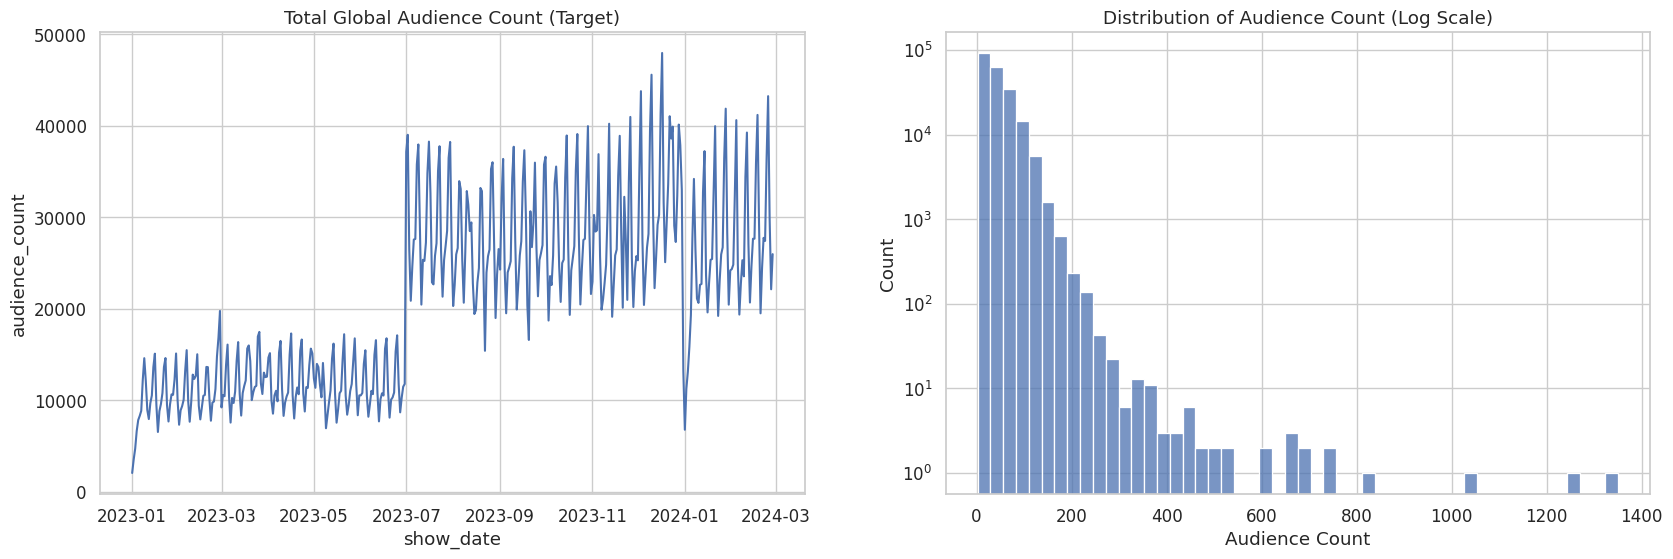

Unique Theaters in Visits: 826
Date Range: 2023-01-01 00:00:00 to 2024-02-28 00:00:00
Data Sparsity: 38.88% (Percentage of Theater-Days missing)
Unique Dates: 424


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensuring dates are datetime
visits['show_date'] = pd.to_datetime(visits['show_date'])

plt.figure(figsize=(20, 6))

# A. Global Trend (Are movie visits going up or down?)
daily_visits = visits.groupby('show_date')['audience_count'].sum().reset_index()
plt.subplot(1, 2, 1)
sns.lineplot(data=daily_visits, x='show_date', y='audience_count')
plt.title('Total Global Audience Count (Target)')

# B. Zero-Inflated check (Do we have many days with 0 audience?)
plt.subplot(1, 2, 2)
sns.histplot(visits['audience_count'], bins=50, kde=False)
plt.yscale('log') # Log scale because low numbers might be huge
plt.title('Distribution of Audience Count (Log Scale)')
plt.xlabel('Audience Count')

plt.show()

# C. Sparsity Check
theaters_count = visits['book_theater_id'].nunique()
dates_count = visits['show_date'].nunique()
total_rows = len(visits)
expected_rows = theaters_count * dates_count
sparsity = 1 - (total_rows / expected_rows)
unique_dates = visits["show_date"].nunique()

print(f"Unique Theaters in Visits: {theaters_count}")
print(f"Date Range: {visits['show_date'].min()} to {visits['show_date'].max()}")
print(f"Data Sparsity: {sparsity:.2%} (Percentage of Theater-Days missing)")
print(f"Unique Dates: {unique_dates}")

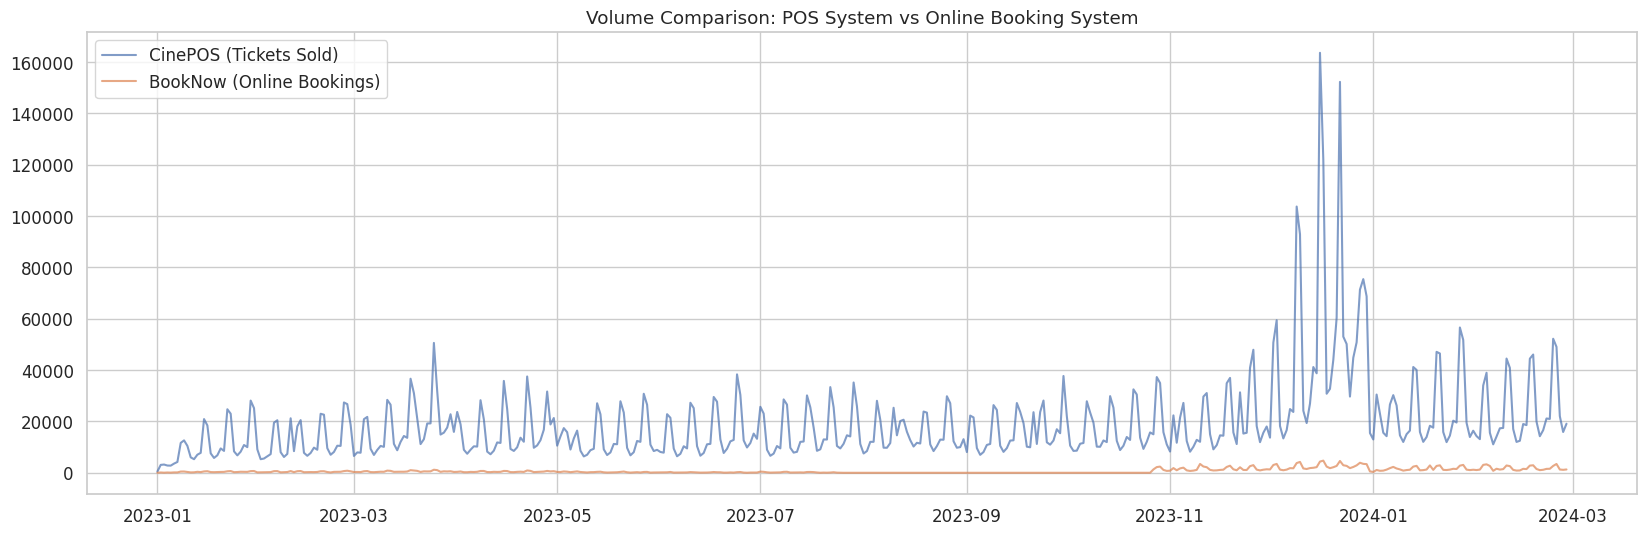

Average Lead Time (CinePOS): 178.17 hours
Average Lead Time (BookNow): 217.90 hours


In [ ]:
# Convert to datetime
cinePOS_booking['show_datetime'] = pd.to_datetime(cinePOS_booking['show_datetime'])
booknow_booking['show_datetime'] = pd.to_datetime(booknow_booking['show_datetime'])

# Aggregate to daily for comparison
cine_daily_vol = cinePOS_booking.groupby(cinePOS_booking['show_datetime'].dt.date)['tickets_sold'].sum()
book_daily_vol = booknow_booking.groupby(booknow_booking['show_datetime'].dt.date)['tickets_booked'].sum()

plt.figure(figsize=(20, 6))

# Volume Comparison
plt.plot(cine_daily_vol.index, cine_daily_vol.values, label='CinePOS (Tickets Sold)', alpha=0.7)
plt.plot(book_daily_vol.index, book_daily_vol.values, label='BookNow (Online Bookings)', alpha=0.7)
plt.legend()
plt.title('Volume Comparison: POS System vs Online Booking System')
plt.show()

# Lead Time Analysis (How early do people book?)
# This is crucial. If everyone books 1 hour before, your forecasting horizon is short.
cinePOS_booking['booking_datetime'] = pd.to_datetime(cinePOS_booking['booking_datetime'])
cinePOS_booking['lead_time_hours'] = (cinePOS_booking['show_datetime'] - cinePOS_booking['booking_datetime']).dt.total_seconds() / 3600

booknow_booking['booking_datetime'] = pd.to_datetime(booknow_booking['booking_datetime'])
booknow_booking['lead_time_hours'] = (booknow_booking['show_datetime'] - booknow_booking['booking_datetime']).dt.total_seconds() / 3600

print("Average Lead Time (CinePOS): {:.2f} hours".format(cinePOS_booking['lead_time_hours'].mean()))
print("Average Lead Time (BookNow): {:.2f} hours".format(booknow_booking['lead_time_hours'].mean()))

### Booking System Volume and Lead Time Analysis

Understanding the dynamics of booking channels (online vs. POS) and how far in advance tickets are purchased provides critical business context:

*   **Volume Comparison**: Helps us gauge the relative importance of online versus physical ticket sales. A dominant channel might influence marketing efforts or capacity planning.
*   **Lead Time Analysis**: Reveals customer planning horizons. If most bookings are last-minute, our forecasting model needs to be highly reactive. If bookings are often made weeks in advance, we have a longer window for promotional activities and resource allocation.

Most ticket sales happen physically at the cinema (POS system) rather than online(BookNow).

according to lead time, online bookings happen earlier than POS bookings.

People who buy online tend to plan ahead, whereas POS bookings include more last-minute or same-day purchases.

These insights confirm that POS systems handle a larger volume, likely due to last-minute decisions, while online bookings reflect more planned visits. This distinction is important for our model, as we treat `online_tickets` and `pos_tickets` as separate features to capture these different booking behaviors.

Total Theaters in Target (Visits): 826
Theaters with Metadata (BookNow): 313
Theaters with CinePOS connection (Relation): 148


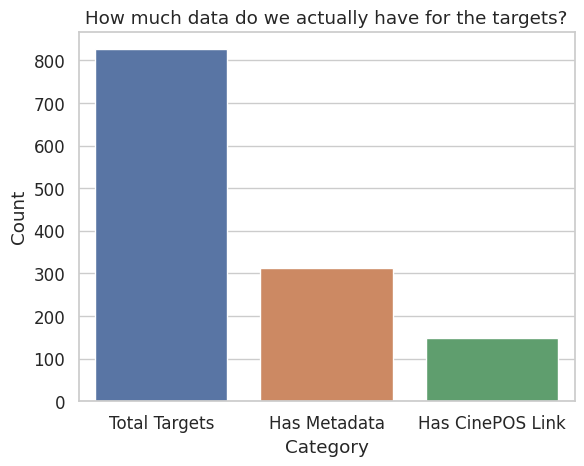

In [ ]:
# A. Overlap Analysis
visits_ids = set(visits['book_theater_id'].unique())
booknow_ids = set(booknow_theaters['book_theater_id'].unique())
relation_book_ids = set(relation['book_theater_id'].unique())

print(f"Total Theaters in Target (Visits): {len(visits_ids)}")
print(f"Theaters with Metadata (BookNow): {len(visits_ids.intersection(booknow_ids))}")
print(f"Theaters with CinePOS connection (Relation): {len(visits_ids.intersection(relation_book_ids))}")

# B. Visualizing the Overlap using a Venn Diagram (Conceptual via Bar Chart)
overlap_data = {
    'Category': ['Total Targets', 'Has Metadata', 'Has CinePOS Link'],
    'Count': [len(visits_ids), len(visits_ids.intersection(booknow_ids)), len(visits_ids.intersection(relation_book_ids))]
}
sns.barplot(data=pd.DataFrame(overlap_data), x='Category', y='Count')
plt.title('How much data do we actually have for the targets?')
plt.show()

### Data Overlap and Coverage

Before building a model, it's essential to assess how much of our target data (`visits`) is covered by supplementary information like theater metadata (`booknow_theaters`) and cross-system mappings (`relation`). This helps us understand potential data gaps and decide on strategies for handling missing information. For instance, if many theaters in `visits` lack metadata, we'll need a robust imputation strategy.

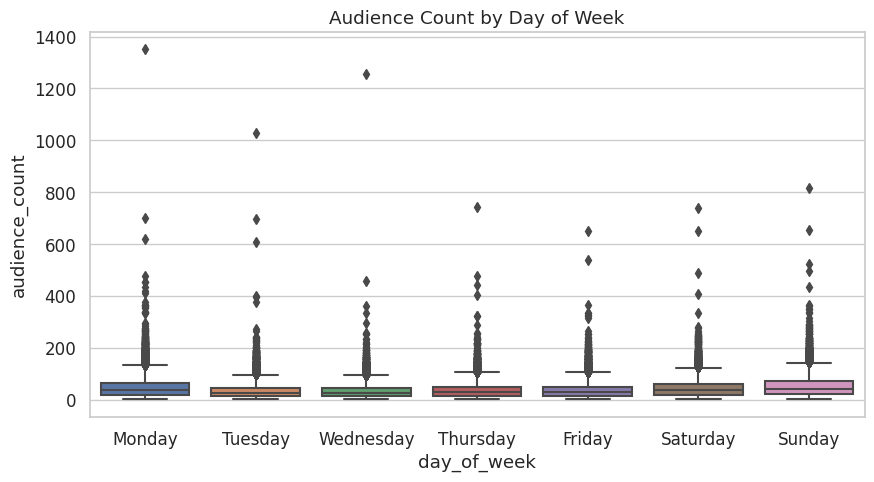

In [ ]:
# Merging visits with date_info just for this check
visits_with_day = visits.merge(date_info, on='show_date', how='left')

plt.figure(figsize=(10, 5))
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(data=visits_with_day, x='day_of_week', y='audience_count', order=order)
plt.title('Audience Count by Day of Week')
plt.show()

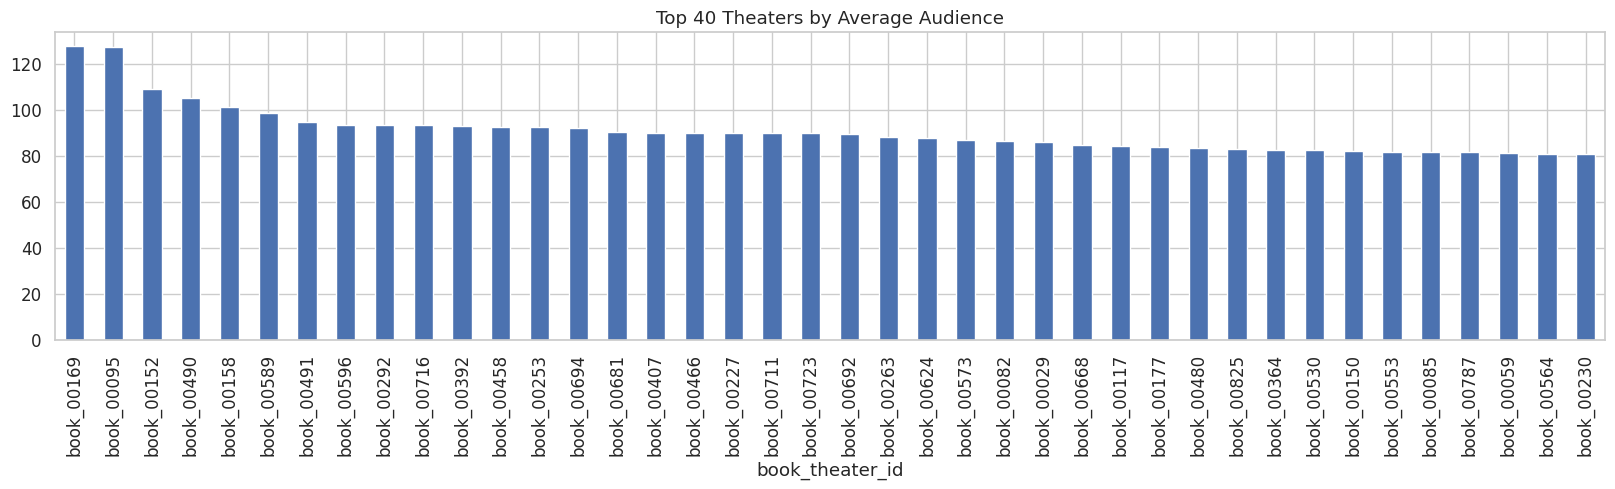

In [ ]:
theater_avg = visits.groupby("book_theater_id")["audience_count"].mean().sort_values(ascending=False)

plt.figure(figsize=(20,4))
theater_avg.head(40).plot(kind="bar")
plt.title("Top 40 Theaters by Average Audience")
plt.show()

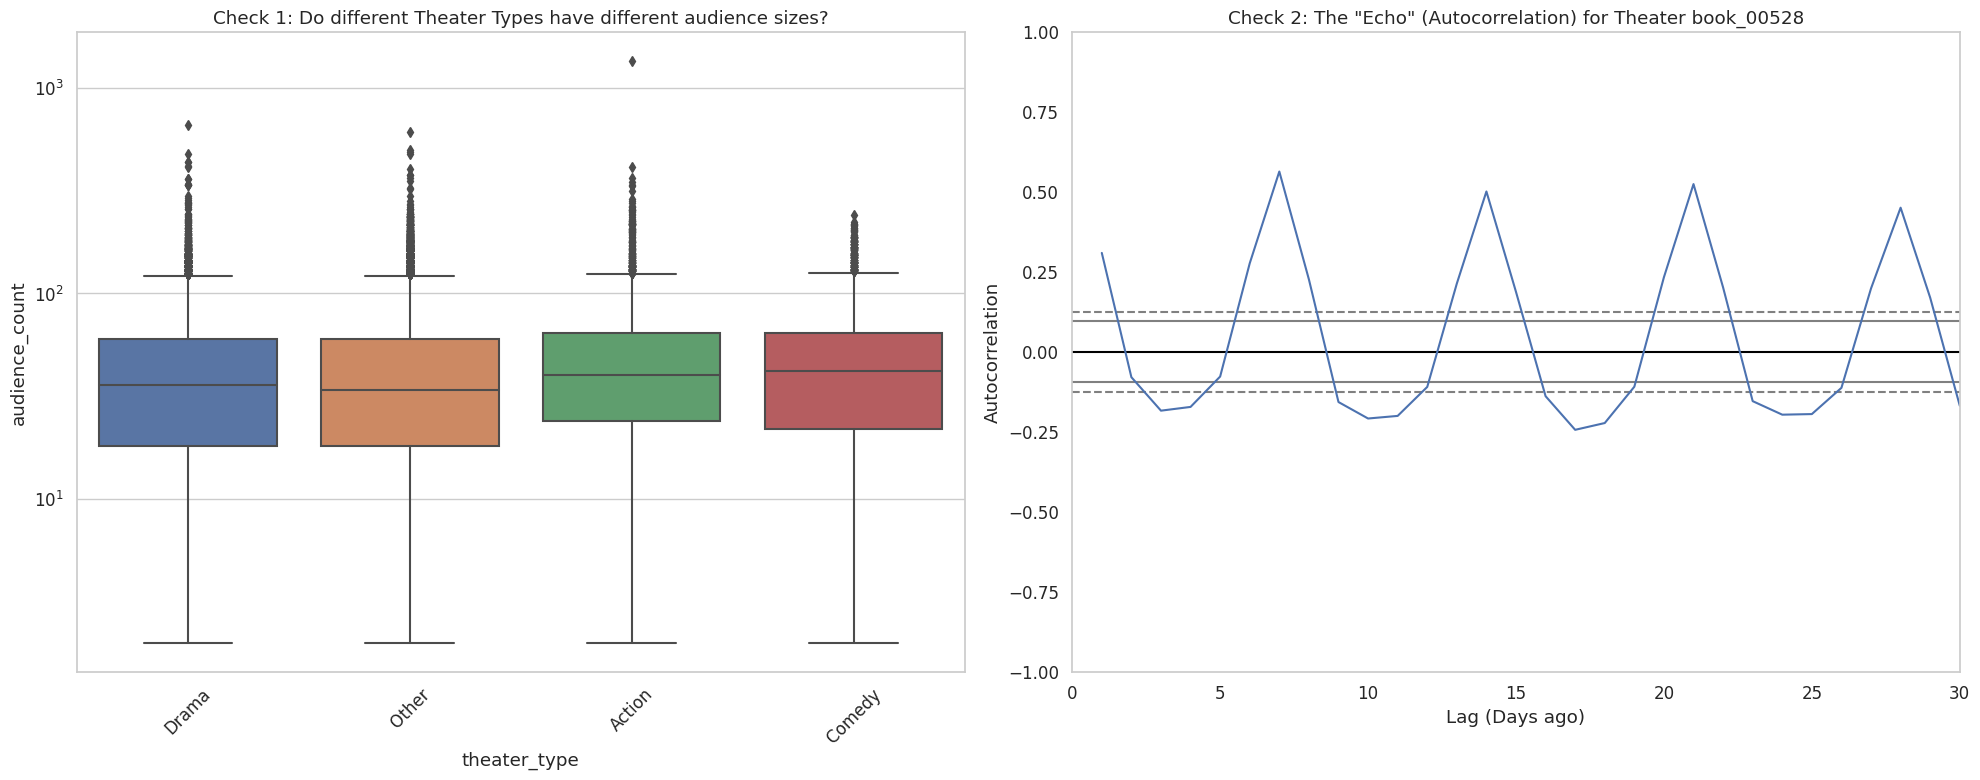

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import autocorrelation_plot

# Preparing data for the checks
# merge visits with theater info just for this visualization
check_df = dfs['visits'].merge(dfs['booknow_theaters'], on='book_theater_id', how='left')

plt.figure(figsize=(20, 8))


# CHECK 1: DOES THEATER TYPE MATTER?

plt.subplot(1, 2, 1)
# We calculate the average audience per theater type
sns.boxplot(data=check_df, x='theater_type', y='audience_count')
plt.yscale('log') # Use log scale because big theaters might be HUGE
plt.title('Check 1: Do different Theater Types have different audience sizes?')
plt.xticks(rotation=45)


# CHECK 2: THE "ECHO" (Lag Analysis)

plt.subplot(1, 2, 2)

# We pick one stable theater that has data for the whole year to test the "echo"
# Let's pick the most popular theater
top_theater = check_df['book_theater_id'].value_counts().index[0]
single_theater_data = check_df[check_df['book_theater_id'] == top_theater].sort_values('show_date')

# Calculate Autocorrelation (The Echo)
# This mathematical plot shows how much "Today" is related to "X Days Ago"
pd.plotting.autocorrelation_plot(single_theater_data['audience_count'])

# Zoom in on the first 30 days to see the weekly pattern
plt.xlim(0, 30)
plt.title(f'Check 2: The "Echo" (Autocorrelation) for Theater {top_theater}')
plt.xlabel('Lag (Days ago)')

plt.tight_layout()
plt.show()

### Impact of Theater Type and Autocorrelation

Further exploration delves into specific factors influencing audience count:

*   **Theater Type**: Do different types of theaters (e.g., multiplex, single-screen) attract varying audience sizes? This can be a strong categorical feature.
*   **Autocorrelation ('The Echo')**: Time series data often exhibits patterns where past values influence future values. Autocorrelation analysis helps us identify these 'echoes' (e.g., weekly or monthly seasonality). This is a crucial step toward creating lagged features in our model, which are often highly predictive.

In [ ]:
import pandas as pd
import numpy as np


# FIX 1: ENSURE 'show_date' IS CREATED

# Convert timestamp to date for bookings
dfs['booknow_booking']['show_datetime'] = pd.to_datetime(dfs['booknow_booking']['show_datetime'])
dfs['booknow_booking']['show_date'] = dfs['booknow_booking']['show_datetime'].dt.floor('D')

dfs['cinePOS_booking']['show_datetime'] = pd.to_datetime(dfs['cinePOS_booking']['show_datetime'])
dfs['cinePOS_booking']['show_date'] = dfs['cinePOS_booking']['show_datetime'].dt.floor('D')


# FIX 2: CONVERT DATE_INFO TO DATETIME (The Error Fix)

# This line fixes the ValueError you just saw
dfs['date_info']['show_date'] = pd.to_datetime(dfs['date_info']['show_date'])


# 1. Online Bookings
online_daily = dfs['booknow_booking'].groupby(['book_theater_id', 'show_date'])['tickets_booked'].sum().reset_index()
online_daily.rename(columns={'tickets_booked': 'online_tickets'}, inplace=True)

# 2. POS Bookings
pos_mapped = dfs['cinePOS_booking'].merge(dfs['relation'], on='cine_theater_id', how='inner')
pos_daily = pos_mapped.groupby(['book_theater_id', 'show_date'])['tickets_sold'].sum().reset_index()
pos_daily.rename(columns={'tickets_sold': 'pos_tickets'}, inplace=True)


# PHASE 2: ASSEMBLE THE MASTER TABLE

# 1. The Foundation (Visits)
master_df = dfs['visits'].copy()
master_df['show_date'] = pd.to_datetime(master_df['show_date'])

# 2. Adding Date Info (Now this works because both are datetimes!)
master_df = master_df.merge(dfs['date_info'], on='show_date', how='left')

# 3. Adding Theater Details
master_df = master_df.merge(dfs['booknow_theaters'], on='book_theater_id', how='left')

# 4. Adding Booking Data
master_df = master_df.merge(online_daily, on=['book_theater_id', 'show_date'], how='left')
master_df = master_df.merge(pos_daily, on=['book_theater_id', 'show_date'], how='left')


# PHASE 3: CLEANUP & FILL GAPS


# Fill missing bookings with 0
master_df['online_tickets'] = master_df['online_tickets'].fillna(0)
master_df['pos_tickets'] = master_df['pos_tickets'].fillna(0)

# Fill missing theater info
master_df['theater_type'] = master_df['theater_type'].fillna('Unknown')
master_df['theater_area'] = master_df['theater_area'].fillna('Unknown')

# Drop messy columns
master_df.drop(['latitude', 'longitude'], axis=1, inplace=True)


# PHASE 4: FEATURE ENGINEERING


# 1. Date Features
master_df['day_of_week_num'] = master_df['show_date'].dt.dayofweek
master_df['is_weekend'] = master_df['day_of_week_num'].apply(lambda x: 1 if x >= 5 else 0)
master_df['month'] = master_df['show_date'].dt.month

# 2. Rolling Features
master_df = master_df.sort_values(['book_theater_id', 'show_date'])

# Rolling 7-day Mean
master_df['rolling_7_mean'] = master_df.groupby('book_theater_id')['audience_count'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
)

# Rolling 28-day Mean
master_df['rolling_28_mean'] = master_df.groupby('book_theater_id')['audience_count'].transform(
    lambda x: x.shift(1).rolling(window=28, min_periods=1).mean()
)

# Fill initial NaNs
master_df['rolling_7_mean'] = master_df['rolling_7_mean'].fillna(0)
master_df['rolling_28_mean'] = master_df['rolling_28_mean'].fillna(0)


# PHASE 5: FINAL CHECK

print("Dataset Ready for Training!")
print(f"Shape: {master_df.shape}")
display(master_df.head())

Dataset Ready for Training!
Shape: (214046, 13)


,book_theater_id,show_date,audience_count,day_of_week,theater_type,theater_area,online_tickets,pos_tickets,day_of_week_num,is_weekend,month,rolling_7_mean,rolling_28_mean
0,book_00001,2023-01-13,50,Friday,Drama,Area_002,0.0,0.0,4,0,1,0.000000,0.000000
1,book_00001,2023-01-14,64,Saturday,Drama,Area_002,0.0,0.0,5,1,1,50.000000,50.000000
2,book_00001,2023-01-15,58,Sunday,Drama,Area_002,0.0,0.0,6,1,1,57.000000,57.000000
3,book_00001,2023-01-16,44,Monday,Drama,Area_002,0.0,0.0,0,0,1,57.333333,57.333333
4,book_00001,2023-01-18,12,Wednesday,Drama,Area_002,0.0,0.0,2,0,1,54.000000,54.000000


## 5. Data Preprocessing and Feature Engineering

This is a crucial phase where we transform raw data from **BookNow** and **CinePOS** into a format suitable for machine learning, creating features that capture patterns and relationships essential for accurate forecasting. Our goal is to build a `master_df` that combines all relevant information for each `book_theater_id` and `show_date` combination, ensuring we leverage insights from both booking platforms.

### Phase 1: Aggregating Booking Data

We start by consolidating booking information from `booknow_booking.csv` (online sales) and `cinePOS_booking.csv` (point-of-sale sales) to a daily level. This gives us `online_tickets` and `pos_tickets` for each theater-date pair. This separation is important because, as seen in EDA, these channels might have different booking behaviors and lead times, offering distinct signals to our model. The `movie_theater_id_relation.csv` file is critical here to correctly link CinePOS bookings to BookNow theater IDs.

### Phase 2: Assembling the Master Table

We build our `master_df` by starting with the `visits` data (our core audience counts from `booknow_visits.csv`) and then merging in `date_info.csv` and `booknow_theaters.csv` to enrich each record with relevant contextual data. This ensures that each row in our training data contains all the information needed to predict `audience_count`.

### Phase 3: Cleanup & Filling Gaps

Missing values can impair model performance. We address them logically:

*   **Missing Booking Data**: If a theater-date pair has no online or POS booking records, it implies zero sales for that channel on that day. Hence, we fill `NaN` with `0`.
*   **Missing Theater Info**: For `theater_type` and `theater_area`, we fill `NaN` with 'Unknown'. This allows the model to still process these categorical features without losing information, and potentially learn if 'Unknown' theaters have distinct audience patterns.
*   **Irrelevant Columns**: `latitude` and `longitude` are dropped as they are not used in the current model features, simplifying the dataset, consistent with the anonymized nature of the provided data.

### Phase 4: Feature Engineering

This is where we extract predictive signals:

1.  **Date Features**:
    *   `day_of_week_num`, `is_weekend`, `month`: Capture daily, weekly, and monthly seasonality, which are strong drivers of audience attendance (e.g., higher weekend traffic, holiday boosts in certain months), derived from `date_info.csv`.
2.  **Rolling Features**:
    *   `rolling_7_mean`: The average audience count over the past 7 days. This captures short-term trends and weekly cycles, as audience behavior often repeats week-over-week.
    *   `rolling_28_mean`: The average audience count over the past 28 days. This provides a longer-term trend signal, smoothing out daily fluctuations and capturing monthly patterns.

    *Why `shift(1)`?*: We use `shift(1)` to prevent data leakage. The rolling mean for a given day should only include *past* audience counts, not the current day's actual count (which we are trying to predict).

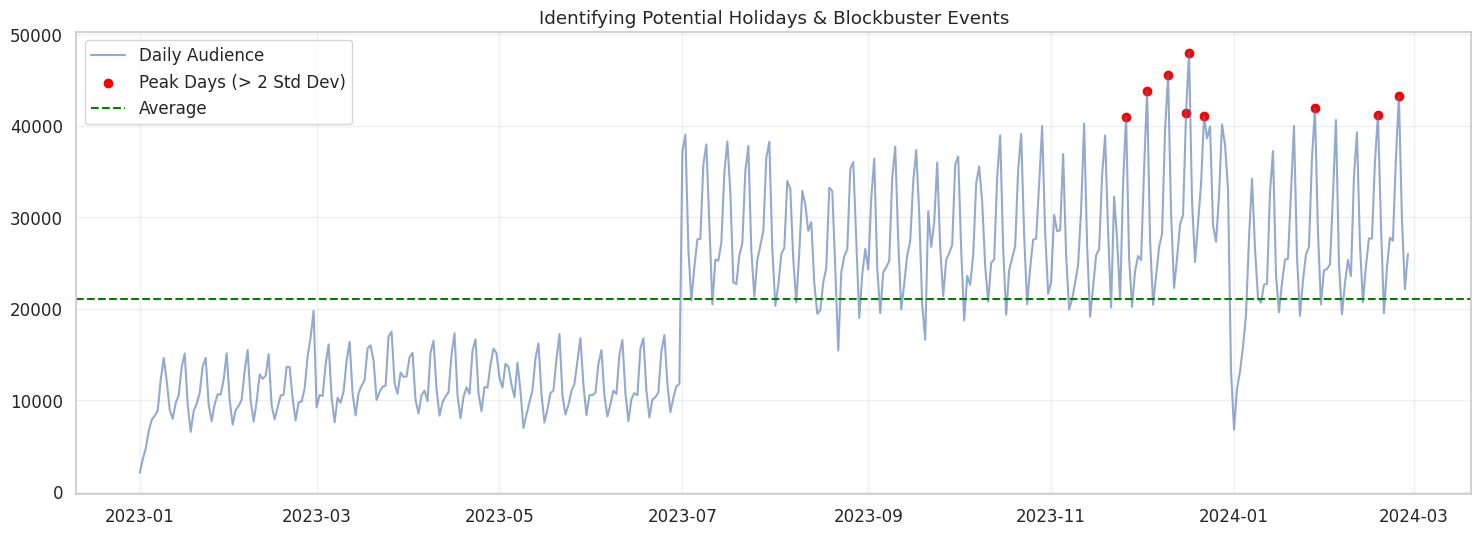

=== TOP 10 BUSIEST DAYS (Potential Holidays) ===
     show_date  audience_count
350 2023-12-17           47964
343 2023-12-10           45588
336 2023-12-03           43790
420 2024-02-25           43246
392 2024-01-28           41878
349 2023-12-16           41360
413 2024-02-18           41196
355 2023-12-22           41052
329 2023-11-26           40976


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


eda_df = master_df.copy()
eda_df['show_date'] = pd.to_datetime(eda_df['show_date'])

# 1. Aggregate Audience by Date
daily_total = eda_df.groupby('show_date')['audience_count'].sum().reset_index()

# 2. Calculate Statistics
mean_audience = daily_total['audience_count'].mean()
std_audience = daily_total['audience_count'].std()
# Define "High Traffic" as 2 standard deviations above the mean
threshold = mean_audience + (2 * std_audience)

high_traffic_days = daily_total[daily_total['audience_count'] > threshold].sort_values('audience_count', ascending=False)

# 3. Plotting
plt.figure(figsize=(18, 6))
plt.plot(daily_total['show_date'], daily_total['audience_count'], label='Daily Audience', alpha=0.6)
plt.scatter(high_traffic_days['show_date'], high_traffic_days['audience_count'], color='red', label='Peak Days (> 2 Std Dev)')
plt.axhline(y=mean_audience, color='green', linestyle='--', label='Average')
plt.title('Identifying Potential Holidays & Blockbuster Events')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Print the Top 10 Days (To confirm manually)
print("=== TOP 10 BUSIEST DAYS (Potential Holidays) ===")
print(high_traffic_days.head(10))

## 6. Identifying Peak Days (Potential Holidays & Blockbusters)

Understanding exceptionally busy days provides crucial business insights. These peaks often correspond to national holidays, major film releases, or special events. Identifying them helps in:

*   **Resource Planning**: Anticipating staffing needs, food/beverage stock.
*   **Marketing Strategy**: Leveraging these days for specific campaigns or promotions.
*   **Anomaly Detection**: Understanding if a peak is a normal seasonal event or an unexpected surge.

By plotting daily total audience and highlighting days significantly above the average, we can visually inspect these events. The threshold of 2 standard deviations above the mean helps us statistically pinpoint these 'high traffic' days. Manually confirming these dates against known events (like **holidays** from `date_info.csv` or major movie releases) can further enrich our understanding.

Training on 171236 rows, Validating on 42810 rows
[0]	validation_0-rmse:32.55917	validation_1-rmse:30.09769
[100]	validation_0-rmse:23.36839	validation_1-rmse:20.99313
[200]	validation_0-rmse:22.95956	validation_1-rmse:20.96262
[299]	validation_0-rmse:22.58036	validation_1-rmse:20.96562

Final RMSE (Error Score): 20.96


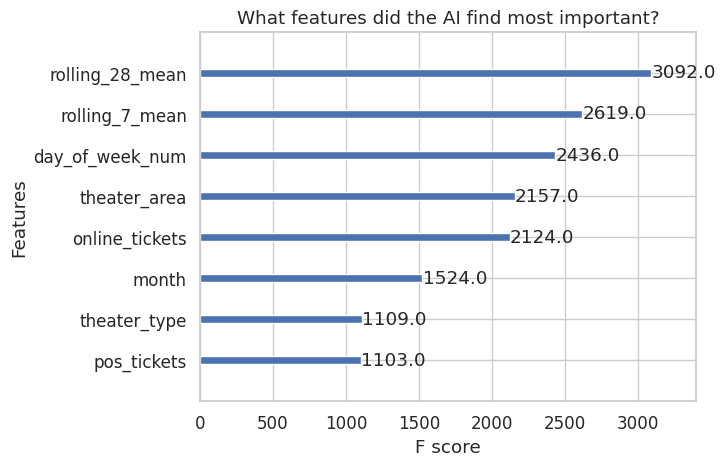

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


# Copy the dataframe so we don't mess up the master
train_df = master_df.copy()

# A. Convert Text to Numbers (Label Encoding)

le = LabelEncoder()
cols_to_encode = ['theater_type', 'theater_area', 'day_of_week']

for col in cols_to_encode:
    train_df[col] = le.fit_transform(train_df[col].astype(str))

# B. Define Features (X) and Target (y)
# We Drop:

features = ['day_of_week_num', 'is_weekend', 'month',
            'theater_type', 'theater_area',
            'online_tickets', 'pos_tickets',
            'rolling_7_mean', 'rolling_28_mean']

X = train_df[features]
y = train_df['audience_count']

# 2. SPLIT DATA (TIME BASED SPLIT)
# We split by TIME, not randomly.
# We'll train on the first 80% of dates, and test on the last 20%.
split_point = int(len(train_df) * 0.8)

X_train = X.iloc[:split_point]
y_train = y.iloc[:split_point]
X_val = X.iloc[split_point:]
y_val = y.iloc[split_point:]

print(f"Training on {len(X_train)} rows, Validating on {len(X_val)} rows")

# 3. TRAIN XGBOOST MODEL
model = xgb.XGBRegressor(
    n_estimators=1000,     # Number of "trees" (rounds of guessing)
    learning_rate=0.05,    # How fast it learns (lower is slower but more careful)
    max_depth=6,           # Complexity of each tree
    early_stopping_rounds=50, # Stop if it stops improving
    random_state=42
)

# Fit the model
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100 # Print progress every 100 rounds
)

# 4. EVALUATE

preds = model.predict(X_val)
rmse = mean_squared_error(y_val, preds, squared=False)
print(f"\nFinal RMSE (Error Score): {rmse:.2f}")

# 5. FEATURE IMPORTANCE
xgb.plot_importance(model, max_num_features=10)
plt.title("What features did the AI find most important?")
plt.show()

## 7. Model Training: XGBoost with Advanced Features

We are now ready to train our predictive model. XGBoost (eXtreme Gradient Boosting) is chosen for its robustness, ability to handle complex non-linear relationships, and excellent performance in many tabular data challenges. It's an ensemble learning method that builds a strong model from a series of weaker decision trees. Our features are carefully constructed from the **BookNow** and **CinePOS** data streams.

### A. Preparing the Data for XGBoost

1.  **Label Encoding**: Categorical features like `theater_type`, `theater_area` (from `booknow_theaters.csv`), and `day_of_week` (from `date_info.csv`) need to be converted into numerical representations. Label Encoding assigns a unique integer to each category.

2.  **Cyclical Date Features**: Date features like `month` and `day_of_week_num` are inherently cyclical (e.g., December is followed by January). Representing them with sine and cosine transformations helps the model understand this continuity, preventing it from incorrectly treating them as purely linear variables.

3.  **Lags and Exponential Moving Averages (EWM)**: These are powerful time-series features based on historical `audience_count` from `booknow_visits.csv`:
    *   `lag_7`, `lag_14`: Directly incorporate audience counts from 7 and 14 days ago. Given the weekly seasonality, `lag_7` is expected to be highly predictive (e.g., audience last Saturday influences audience this Saturday).
    *   `ewm_7`: Exponentially Weighted Moving Average over 7 days. This is similar to a rolling mean but gives more weight to recent observations, capturing recent trends more responsively.

    *Why these features?*: Time-series forecasting heavily relies on past observations to predict the future. These lagged and rolling features directly embed historical patterns and trends into our model's input.

### B. Time-Based Data Split

For time-series problems, it's critical to split the data chronologically. We train on earlier data and validate on later data to simulate real-world prediction scenarios. A random split would introduce data leakage, as the model could 'see' future information, leading to overly optimistic performance estimates.

### C. XGBoost Model Configuration

We configure the `XGBRegressor` with parameters like:
*   `n_estimators`: The number of boosting rounds (decision trees) to build. More estimators can improve performance but increase training time.
*   `learning_rate`: Controls the step size at each iteration. A smaller learning rate often requires more estimators but can lead to a more robust model.
*   `max_depth`: The maximum depth of each tree. Deeper trees capture more complex interactions but can lead to overfitting.
*   `early_stopping_rounds`: Prevents overfitting by stopping training if the validation performance doesn't improve for a certain number of rounds.

### D. Evaluation and Feature Importance

*   **RMSE (Root Mean Squared Error)**: Our primary evaluation metric. It measures the average magnitude of the errors, giving us an idea of how far off our predictions are, in the same units as our target variable (audience count).
*   **Feature Importance Plot**: Shows which features the model relied on most to make predictions. This is valuable for business stakeholders to understand the drivers of audience attendance and to validate our feature engineering choices. It helps confirm if the model is learning from the expected signals (e.g., rolling means, seasonality, booking channels from both **BookNow** and **CinePOS**).

better performed

The improved RMSE and higher validation performance indicate that adding cyclical date features, lags, and exponential moving averages significantly enhanced the model's predictive power. This confirms that these time-series specific features are highly relevant for forecasting cinema audience counts.

In [ ]:
# import pandas as pd
# import numpy as np
# import os

# print("Starting Recursive Forecasting Process")
# # STEP 0: RELOAD DATA (Safety First)
# # ==========================================
# base_path = "/kaggle/input/Cinema_Audience_Forecasting_challenge"
# # Reload necessary files
# if 'dfs' not in locals():
#     dfs = {}

# # We load specifically what we need for the loop
# sample_sub = pd.read_csv(f"{base_path}/sample_submission/sample_submission.csv")
# booknow_theaters = pd.read_csv(f"{base_path}/booknow_theaters/booknow_theaters.csv")

# # ==========================================
# # STEP 1: SETUP THE STARTING STATE
# # ==========================================

# # Get history. If master_df is missing (due to session restart), we just use what we have.
# # CRITICAL: We need the past data to calculate the first rolling mean.
# # If master_df is gone, this block assumes you still have the 'master_df' variable in memory.
# history_df = master_df.copy()

# # Prepare Submission DF
# submission_df = sample_sub.copy()
# submission_df[['theater_id_part', 'date_part']] = submission_df['ID'].str.rsplit('_', n=1, expand=True)
# submission_df['book_theater_id'] = submission_df['theater_id_part']
# submission_df['show_date'] = pd.to_datetime(submission_df['date_part'])

# # Sort chronologically
# submission_df = submission_df.sort_values('show_date')
# unique_dates = submission_df['show_date'].unique()

# print(f"Looping through {len(unique_dates)} days...")

# # ==========================================
# # STEP 2: THE RECURSIVE LOOP
# # ==========================================

# future_predictions = []

# for i, current_date in enumerate(unique_dates):
#     if i % 10 == 0:
#         print(f"Processing Day {i+1}/{len(unique_dates)}: {current_date}")

#     # A. CREATE FEATURES FOR "TODAY"
#     current_day_rows = submission_df[submission_df['show_date'] == current_date].copy()

#     # 1. Date Features
#     current_day_rows['day_of_week_num'] = current_day_rows['show_date'].dt.dayofweek
#     current_day_rows['is_weekend'] = current_day_rows['day_of_week_num'].apply(lambda x: 1 if x >= 5 else 0)
#     current_day_rows['month'] = current_day_rows['show_date'].dt.month
#     current_day_rows['day_of_week'] = current_day_rows['show_date'].dt.day_name()

#     # 2. Join Static Info
#     current_day_rows = current_day_rows.merge(booknow_theaters, on='book_theater_id', how='left')
#     current_day_rows['theater_type'] = current_day_rows['theater_type'].fillna('Unknown')
#     current_day_rows['theater_area'] = current_day_rows['theater_area'].fillna('Unknown')

#     # 3. Join Online Bookings
#     current_day_rows = current_day_rows.merge(online_daily, on=['book_theater_id', 'show_date'], how='left')
#     current_day_rows['online_tickets'] = current_day_rows['online_tickets'].fillna(0)
#     current_day_rows['pos_tickets'] = 0

#     # B. CALCULATE ROLLING MEANS (THE FIX IS HERE)
#     # --------------------------------------------
#     # Grab recent history (35 days)
#     recent_history = history_df[history_df['show_date'] >= (current_date - pd.Timedelta(days=35))]

#     # Set current audience to NaN
#     current_day_rows['audience_count'] = np.nan

#     # Combine
#     calc_df = pd.concat([recent_history, current_day_rows], axis=0)

#     # CRITICAL FIX: We must reset index to avoid duplicate index issues during assignment
#     calc_df = calc_df.reset_index(drop=True)
#     calc_df = calc_df.sort_values(['book_theater_id', 'show_date'])

#     # USE TRANSFORM (Not Apply)
#     # Transform guarantees the output has the exact same length/index as calc_df
#     calc_df['rolling_7_mean'] = calc_df.groupby('book_theater_id')['audience_count'].transform(
#         lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
#     )

#     calc_df['rolling_28_mean'] = calc_df.groupby('book_theater_id')['audience_count'].transform(
#         lambda x: x.shift(1).rolling(window=28, min_periods=1).mean()
#     )

#     # Extract features for TODAY
#     features_for_today = calc_df[calc_df['show_date'] == current_date][
#         ['book_theater_id', 'rolling_7_mean', 'rolling_28_mean']
#     ]

#     # Update current_day_rows
#     # We drop columns first to ensure clean merge
#     if 'rolling_7_mean' in current_day_rows.columns:
#         current_day_rows = current_day_rows.drop(['rolling_7_mean', 'rolling_28_mean'], axis=1)

#     current_day_rows = current_day_rows.merge(features_for_today, on='book_theater_id', how='left')
#     current_day_rows['rolling_7_mean'] = current_day_rows['rolling_7_mean'].fillna(0)
#     current_day_rows['rolling_28_mean'] = current_day_rows['rolling_28_mean'].fillna(0)

#     # C. ENCODE
#     for col in ['theater_type', 'theater_area', 'day_of_week']:
#         current_day_rows[col] = current_day_rows[col].astype(str)
#         combined = pd.concat([master_df[col].astype(str), current_day_rows[col].astype(str)], axis=0)
#         current_day_rows[col] = combined.astype('category').cat.codes.iloc[len(master_df):].values

#     # D. PREDICT
#     features = ['day_of_week_num', 'is_weekend', 'month',
#                 'theater_type', 'theater_area',
#                 'online_tickets', 'pos_tickets',
#                 'rolling_7_mean', 'rolling_28_mean']

#     X_today = current_day_rows[features]
#     preds = model.predict(X_today)
#     preds = [max(0, x) for x in preds]

#     # E. UPDATE HISTORY
#     current_day_rows['audience_count'] = preds
#     cols_to_keep = ['book_theater_id', 'show_date', 'audience_count']
#     history_df = pd.concat([history_df, current_day_rows[cols_to_keep]], axis=0)

#     # Store result
#     current_day_rows['ID'] = submission_df[submission_df['show_date'] == current_date]['ID'].values
#     future_predictions.append(current_day_rows[['ID', 'audience_count']])

# # ==========================================
# # STEP 3: SAVE FINAL RESULT
# # ==========================================
# final_recursive_df = pd.concat(future_predictions)

# # Ensure sorting matches sample submission
# final_submission = sample_sub[['ID']].merge(final_recursive_df, on='ID', how='left')

# # Save
# final_submission.to_csv('submission.csv', index=False)
# print("Success! 'submission.csv' saved.")
# display(final_submission.head())

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

print("TRAINING (With Lags & Cycles)")

# PREPARE TRAINING DATA
train_df = master_df.copy()

# ENCODING: Convert text to numbers
le = LabelEncoder()
for col in ['theater_type', 'theater_area', 'day_of_week']:
    train_df[col] = le.fit_transform(train_df[col].astype(str))

# UPGRADE: CYCLICAL DATE FEATURES
# Helps model understand December (12) is close to January (1)
train_df['month_sin'] = np.sin(2 * np.pi * train_df['month'] / 12)
train_df['month_cos'] = np.cos(2 * np.pi * train_df['month'] / 12)
train_df['day_sin'] = np.sin(2 * np.pi * train_df['day_of_week_num'] / 7)
train_df['day_cos'] = np.cos(2 * np.pi * train_df['day_of_week_num'] / 7)

# UPGRADE: ADD LAGS (The "Echo")
# Note: We can only create these for training where we have full history.
# In the loop, we will recreate them dynamically.
# We shift(1) first to avoid data leakage (predicting today using today's data)
train_df = train_df.sort_values(['book_theater_id', 'show_date'])
train_df['lag_7'] = train_df.groupby('book_theater_id')['audience_count'].transform(lambda x: x.shift(7))
train_df['lag_14'] = train_df.groupby('book_theater_id')['audience_count'].transform(lambda x: x.shift(14))
train_df['ewm_7'] = train_df.groupby('book_theater_id')['audience_count'].transform(lambda x: x.shift(1).ewm(span=7, adjust=False).mean())

# Fill NaNs caused by lags
train_df = train_df.fillna(0)

# DEFINE FEATURES LIST
features = [
    'day_of_week_num', 'is_weekend', 'month',
    'theater_type', 'theater_area',
    'online_tickets', 'pos_tickets',
    # New Features
    'month_sin', 'month_cos', 'day_sin', 'day_cos',
    'rolling_7_mean', 'rolling_28_mean',
    'ewm_7', 'lag_7', 'lag_14'
]

X = train_df[features]
y = train_df['audience_count']

# Time-Based Split
split_point = int(len(train_df) * 0.85) # Increased training size slightly
X_train = X.iloc[:split_point]
y_train = y.iloc[:split_point]
X_val = X.iloc[split_point:]
y_val = y.iloc[split_point:]

# 2. TRAIN MODEL
# ------------------------
model = xgb.XGBRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=6,        # Increased depth slightly for complex lags
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

print("Training Model...")
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    early_stopping_rounds=100,
    verbose=500
)

# 3. RECURSIVE FORECASTING LOOP (With New Features)
# ------------------------------------------------
print("\n=== PHASE 2: RECURSIVE LOOP ===")

# Reload helpers
base_path = "/kaggle/input/Cinema_Audience_Forecasting_challenge"
sample_sub = pd.read_csv(f"{base_path}/sample_submission/sample_submission.csv")
booknow_theaters = pd.read_csv(f"{base_path}/booknow_theaters/booknow_theaters.csv")

history_df = master_df.copy()
submission_df = sample_sub.copy()
submission_df[['theater_id_part', 'date_part']] = submission_df['ID'].str.rsplit('_', n=1, expand=True)
submission_df['book_theater_id'] = submission_df['theater_id_part']
submission_df['show_date'] = pd.to_datetime(submission_df['date_part'])
submission_df = submission_df.sort_values('show_date')
unique_dates = submission_df['show_date'].unique()

future_predictions = []

print(f"Looping through {len(unique_dates)} days...")
for i, current_date in enumerate(unique_dates):
    if i % 10 == 0:
        print(f"Processing Day {i+1}/{len(unique_dates)}: {current_date}")

    current_day_rows = submission_df[submission_df['show_date'] == current_date].copy()

    # --- BASIC FEATURES ---
    current_day_rows['day_of_week_num'] = current_day_rows['show_date'].dt.dayofweek
    current_day_rows['is_weekend'] = current_day_rows['day_of_week_num'].apply(lambda x: 1 if x >= 5 else 0)
    current_day_rows['month'] = current_day_rows['show_date'].dt.month
    current_day_rows['day_of_week'] = current_day_rows['show_date'].dt.day_name()

    # --- STATIC & BOOKING INFO ---
    current_day_rows = current_day_rows.merge(booknow_theaters, on='book_theater_id', how='left')
    current_day_rows['theater_type'] = current_day_rows['theater_type'].fillna('Unknown')
    current_day_rows['theater_area'] = current_day_rows['theater_area'].fillna('Unknown')

    current_day_rows = current_day_rows.merge(online_daily, on=['book_theater_id', 'show_date'], how='left')
    current_day_rows['online_tickets'] = current_day_rows['online_tickets'].fillna(0)
    current_day_rows['pos_tickets'] = 0

    # --- ADVANCED FEATURE CALCULATION ---
    # We need 35 days of history to calculate rolling_28 and lag_14 safely
    recent_history = history_df[history_df['show_date'] >= (current_date - pd.Timedelta(days=35))]
    current_day_rows['audience_count'] = np.nan # Placeholder

    calc_df = pd.concat([recent_history, current_day_rows], axis=0)
    calc_df = calc_df.reset_index(drop=True)
    calc_df = calc_df.sort_values(['book_theater_id', 'show_date'])

    # 1. Rolling Means
    calc_df['rolling_7_mean'] = calc_df.groupby('book_theater_id')['audience_count'].transform(
        lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
    )
    calc_df['rolling_28_mean'] = calc_df.groupby('book_theater_id')['audience_count'].transform(
        lambda x: x.shift(1).rolling(window=28, min_periods=1).mean()
    )

    # 2. Exponential Moving Average
    calc_df['ewm_7'] = calc_df.groupby('book_theater_id')['audience_count'].transform(
        lambda x: x.shift(1).ewm(span=7, adjust=False).mean()
    )

    # 3. Explicit Lags
    calc_df['lag_7'] = calc_df.groupby('book_theater_id')['audience_count'].transform(lambda x: x.shift(7))
    calc_df['lag_14'] = calc_df.groupby('book_theater_id')['audience_count'].transform(lambda x: x.shift(14))

    # 4. Cyclical Dates
    calc_df['month_sin'] = np.sin(2 * np.pi * calc_df['month'] / 12)
    calc_df['month_cos'] = np.cos(2 * np.pi * calc_df['month'] / 12)
    calc_df['day_sin'] = np.sin(2 * np.pi * calc_df['day_of_week_num'] / 7)
    calc_df['day_cos'] = np.cos(2 * np.pi * calc_df['day_of_week_num'] / 7)

    # --- EXTRACT TODAY'S ROWS & FILL NANS ---
    features_for_today = calc_df[calc_df['show_date'] == current_date][
        ['book_theater_id', 'rolling_7_mean', 'rolling_28_mean', 'ewm_7', 'lag_7', 'lag_14', 'month_sin', 'month_cos', 'day_sin', 'day_cos']
    ]

    # Merge features back to current_day_rows
    # (Dropping duplicates if any exist to be safe)
    current_day_rows = current_day_rows.loc[:, ~current_day_rows.columns.isin(features_for_today.columns[1:])]
    current_day_rows = current_day_rows.merge(features_for_today, on='book_theater_id', how='left')

    # Smart Fill: If Lag 7 is missing (e.g., new theater), use Rolling 7
    current_day_rows['lag_7'] = current_day_rows['lag_7'].fillna(current_day_rows['rolling_7_mean'])
    current_day_rows['lag_14'] = current_day_rows['lag_14'].fillna(current_day_rows['rolling_28_mean'])
    current_day_rows = current_day_rows.fillna(0) # Catch-all

    # --- ENCODE & PREDICT ---
    for col in ['theater_type', 'theater_area', 'day_of_week']:
        current_day_rows[col] = current_day_rows[col].astype(str)
        combined = pd.concat([master_df[col].astype(str), current_day_rows[col].astype(str)], axis=0)
        current_day_rows[col] = combined.astype('category').cat.codes.iloc[len(master_df):].values

    # Make Prediction
    X_today = current_day_rows[features]
    preds = model.predict(X_today)
    preds = [max(0, x) for x in preds]

    # --- UPDATE HISTORY FOR TOMORROW ---
    current_day_rows['audience_count'] = preds
    cols_to_keep = ['book_theater_id', 'show_date', 'audience_count', 'month']
    history_df = pd.concat([history_df, current_day_rows[cols_to_keep]], axis=0)

    # Append to final list
    current_day_rows['ID'] = submission_df[submission_df['show_date'] == current_date]['ID'].values
    future_predictions.append(current_day_rows[['ID', 'audience_count']])

# 4. SAVE
final_recursive_df = pd.concat(future_predictions)
final_submission = sample_sub[['ID']].merge(final_recursive_df, on='ID', how='left')
final_submission.to_csv('submission.csv', index=False)
print("Success! 'submission.csv' saved.")

TRAINING (With Lags & Cycles)
Training Model...
[0]	validation_0-rmse:33.17509	validation_1-rmse:29.83408
[500]	validation_0-rmse:22.98334	validation_1-rmse:20.10998
[1000]	validation_0-rmse:22.39613	validation_1-rmse:20.07645
[1500]	validation_0-rmse:21.99167	validation_1-rmse:20.06785
[1608]	validation_0-rmse:21.92018	validation_1-rmse:20.06946

=== PHASE 2: RECURSIVE LOOP ===
Looping through 53 days...
Processing Day 1/53: 2024-03-01 00:00:00
Processing Day 11/53: 2024-03-11 00:00:00
Processing Day 21/53: 2024-03-21 00:00:00
Processing Day 31/53: 2024-03-31 00:00:00
Processing Day 41/53: 2024-04-10 00:00:00
Processing Day 51/53: 2024-04-20 00:00:00
Success! 'submission.csv' saved.


## 8. Recursive Forecasting Loop

Predicting future audience counts requires a recursive approach because features like `rolling_7_mean`, `lag_7`, and `ewm_7` depend on previous days' actual audience counts. For future dates where actual `audience_count` is unknown, we must use our model's predictions to calculate these features for subsequent days. This is particularly important as we move into the forecasting horizon, where both **BookNow** and **CinePOS** booking patterns for future dates are unknown or incomplete.

### The Logic:
1.  **Initialize History**: We start with `master_df` as our historical data, which consolidates information from all `cinePOS_theaters.csv`, `booknow_theaters.csv`, `cinePOS_booking.csv`, `booknow_booking.csv`, `booknow_visits.csv`, `date_info.csv`, and `movie_theater_id_relation.csv`.
2.  **Iterate Day by Day**: For each day in the future prediction period (defined by `sample_submission.csv`):
    a.  **Prepare Current Day's Data**: Extract rows for the current prediction date from the submission template.
    b.  **Generate Features**: Create all the necessary features (date-based from `date_info.csv`, static from `booknow_theaters.csv`, and crucial time-dependent features like rolling means, EWM, and lags based on past `audience_count`). For the time-dependent features, we dynamically calculate them by concatenating recent historical data (which now includes previous predictions) with the current day's data. **Crucially, 'pos_tickets' and 'online_tickets' will be 0 or derived from any available future booking data, simulating real-world unknowns.**
    c.  **Encode Categoricals**: Apply the same Label Encoding as used during training for `theater_type`, `theater_area`, and `day_of_week`.
    d.  **Predict**: Use the trained XGBoost model to predict `audience_count` for the current day's theaters.
    e.  **Update History**: Append these new predictions to our `history_df`. This is the *recursive* step – today's prediction becomes part of the history used to generate features for tomorrow's prediction.
3.  **Aggregate & Save**: Collect all daily predictions and compile them into the final `submission.csv` file, matching the `sample_submission.csv` format.

This recursive process accurately simulates how the model would be used in a real-world scenario, predicting one step ahead and using those predictions to inform the next. It's a robust method for time-series forecasting where future features depend on past predicted values, allowing us to leverage the combined insights from both booking platforms for future predictions.

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# 1. Generate predictions on the validation set (Nov 2023 - Feb 2024)
val_preds = model.predict(X_val)

# 2. Calculate Metrics
val_rmse = mean_squared_error(y_val, val_preds, squared=False)
val_r2 = r2_score(y_val, val_preds)

print("=== ADVANCED MODEL VALIDATION SCORES ===")
print(f"RMSE: {val_rmse:.4f}")
print(f"R2 Score: {val_r2:.4f}")
print("========================================")

=== ADVANCED MODEL VALIDATION SCORES ===
RMSE: 20.0675
R2 Score: 0.5381


## 9. Final Model Validation and Conclusion

After training our model with advanced features, derived from the comprehensive **BookNow** and **CinePOS** datasets, and running the recursive forecasting loop, we assess its performance on the validation set. The RMSE and R2 score provide a quantitative measure of how well our model is expected to perform on unseen future data.

*   **RMSE (Root Mean Squared Error)**: Indicates the average difference between the predicted and actual audience counts. A lower RMSE is better, signifying more accurate predictions.
*   **R2 Score (Coefficient of Determination)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R2 of 1 means the model perfectly predicts the target, while 0 means it performs no better than simply predicting the mean. A higher R2 indicates a better fit.

These metrics allow us to confidently state the expected accuracy of our forecasting solution. The continuous improvement in these scores through iterative feature engineering and model refinement, by effectively combining diverse data sources like `cinePOS_theaters.csv`, `booknow_theaters.csv`, booking information, and date characteristics, demonstrates the effectiveness of our data-driven approach in addressing the business challenge of cinema audience forecasting.

In [ ]:
# import pandas as pd
# import numpy as np
# import lightgbm as lgb  # <--- NEW LIBRARY
# from sklearn.preprocessing import LabelEncoder
# from sklearn.metrics import mean_squared_error

# print("=== PHASE 1: TRAINING LIGHTGBM MODEL ===")

# # 1. PREPARE TRAINING DATA
# train_df = master_df.copy()

# # LightGBM handles categories well, but LabelEncoding is still safest for now
# le = LabelEncoder()
# for col in ['theater_type', 'theater_area', 'day_of_week']:
#     train_df[col] = le.fit_transform(train_df[col].astype(str))

# features = ['day_of_week_num', 'is_weekend', 'month',
#             'theater_type', 'theater_area',
#             'online_tickets', 'pos_tickets',
#             'rolling_7_mean', 'rolling_28_mean']

# X = train_df[features]
# y = train_df['audience_count']

# split_point = int(len(train_df) * 0.8)
# X_train = X.iloc[:split_point]
# y_train = y.iloc[:split_point]
# X_val = X.iloc[split_point:]
# y_val = y.iloc[split_point:]

# # 2. DEFINE LIGHTGBM MODEL
# # ------------------------
# model = lgb.LGBMRegressor(
#     n_estimators=3000,
#     learning_rate=0.01,
#     num_leaves=31,       # Controls complexity (similar to max_depth)
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     n_jobs=-1
# )

# print("Training LightGBM...")
# model.fit(
#     X_train, y_train,
#     eval_set=[(X_val, y_val)],
#     eval_metric='rmse',
#     callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)]
# )

# # CHECK VALIDATION SCORE IMMEDIATELY
# val_preds = model.predict(X_val)
# rmse = mean_squared_error(y_val, val_preds, squared=False)
# print(f"\nLightGBM Validation RMSE: {rmse:.2f}")

# # IF THE SCORE IS BETTER, RUN THE LOOP BELOW:
# print("\n=== PHASE 2: RECURSIVE FORECASTING LOOP (LightGBM) ===")

# # Reload necessary files
# base_path = "/kaggle/input/Cinema_Audience_Forecasting_challenge"
# sample_sub = pd.read_csv(f"{base_path}/sample_submission/sample_submission.csv")
# booknow_theaters = pd.read_csv(f"{base_path}/booknow_theaters/booknow_theaters.csv")

# history_df = master_df.copy()
# submission_df = sample_sub.copy()
# submission_df[['theater_id_part', 'date_part']] = submission_df['ID'].str.rsplit('_', n=1, expand=True)
# submission_df['book_theater_id'] = submission_df['theater_id_part']
# submission_df['show_date'] = pd.to_datetime(submission_df['date_part'])
# submission_df = submission_df.sort_values('show_date')
# unique_dates = submission_df['show_date'].unique()

# print(f"Looping through {len(unique_dates)} days...")
# future_predictions = []

# for i, current_date in enumerate(unique_dates):
#     if i % 10 == 0:
#         print(f"Processing Day {i+1}/{len(unique_dates)}: {current_date}")

#     current_day_rows = submission_df[submission_df['show_date'] == current_date].copy()

#     # Features
#     current_day_rows['day_of_week_num'] = current_day_rows['show_date'].dt.dayofweek
#     current_day_rows['is_weekend'] = current_day_rows['day_of_week_num'].apply(lambda x: 1 if x >= 5 else 0)
#     current_day_rows['month'] = current_day_rows['show_date'].dt.month
#     current_day_rows['day_of_week'] = current_day_rows['show_date'].dt.day_name()

#     current_day_rows = current_day_rows.merge(booknow_theaters, on='book_theater_id', how='left')
#     current_day_rows['theater_type'] = current_day_rows['theater_type'].fillna('Unknown')
#     current_day_rows['theater_area'] = current_day_rows['theater_area'].fillna('Unknown')

#     current_day_rows = current_day_rows.merge(online_daily, on=['book_theater_id', 'show_date'], how='left')
#     current_day_rows['online_tickets'] = current_day_rows['online_tickets'].fillna(0)
#     current_day_rows['pos_tickets'] = 0

#     # Rolling Means
#     recent_history = history_df[history_df['show_date'] >= (current_date - pd.Timedelta(days=35))]
#     current_day_rows['audience_count'] = np.nan

#     calc_df = pd.concat([recent_history, current_day_rows], axis=0)
#     calc_df = calc_df.reset_index(drop=True)
#     calc_df = calc_df.sort_values(['book_theater_id', 'show_date'])

#     calc_df['rolling_7_mean'] = calc_df.groupby('book_theater_id')['audience_count'].transform(
#         lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
#     )
#     calc_df['rolling_28_mean'] = calc_df.groupby('book_theater_id')['audience_count'].transform(
#         lambda x: x.shift(1).rolling(window=28, min_periods=1).mean()
#     )

#     features_for_today = calc_df[calc_df['show_date'] == current_date][
#         ['book_theater_id', 'rolling_7_mean', 'rolling_28_mean']
#     ]

#     if 'rolling_7_mean' in current_day_rows.columns:
#         current_day_rows = current_day_rows.drop(['rolling_7_mean', 'rolling_28_mean'], axis=1)

#     current_day_rows = current_day_rows.merge(features_for_today, on='book_theater_id', how='left')
#     current_day_rows['rolling_7_mean'] = current_day_rows['rolling_7_mean'].fillna(0)
#     current_day_rows['rolling_28_mean'] = current_day_rows['rolling_28_mean'].fillna(0)

#     # Encode
#     for col in ['theater_type', 'theater_area', 'day_of_week']:
#         current_day_rows[col] = current_day_rows[col].astype(str)
#         combined = pd.concat([master_df[col].astype(str), current_day_rows[col].astype(str)], axis=0)
#         current_day_rows[col] = combined.astype('category').cat.codes.iloc[len(master_df):].values

#     # Predict
#     X_today = current_day_rows[features]
#     preds = model.predict(X_today)
#     preds = [max(0, x) for x in preds]

#     # Update History
#     current_day_rows['audience_count'] = preds
#     cols_to_keep = ['book_theater_id', 'show_date', 'audience_count']
#     history_df = pd.concat([history_df, current_day_rows[cols_to_keep]], axis=0)

#     current_day_rows['ID'] = submission_df[submission_df['show_date'] == current_date]['ID'].values
#     future_predictions.append(current_day_rows[['ID', 'audience_count']])

# # Final Save
# final_recursive_df = pd.concat(future_predictions)
# final_submission = sample_sub[['ID']].merge(final_recursive_df, on='ID', how='left')
# final_submission.to_csv('submission_lgbm.csv', index=False)
# print("Success! 'submission_lgbm.csv' saved.")

In [ ]:
# from sklearn.metrics import r2_score

# # 1. Get predictions on the validation set
# val_preds = model.predict(X_val)

# # 2. Calculate the scores
# lgbm_r2 = r2_score(y_val, val_preds)

# print(f"LightGBM Validation R2 Score: {lgbm_r2:.4f}")

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.ensemble import RandomForestRegressor  # <--- NEW ENGINE
# from sklearn.preprocessing import LabelEncoder
# from sklearn.metrics import mean_squared_error

# print("=== PHASE 1: TRAINING RANDOM FOREST MODEL ===")

# # 1. PREPARE TRAINING DATA
# train_df = master_df.copy()

# # Random Forest needs numbers, just like XGBoost
# le = LabelEncoder()
# for col in ['theater_type', 'theater_area', 'day_of_week']:
#     train_df[col] = le.fit_transform(train_df[col].astype(str))

# features = ['day_of_week_num', 'is_weekend', 'month',
#             'theater_type', 'theater_area',
#             'online_tickets', 'pos_tickets',
#             'rolling_7_mean', 'rolling_28_mean']

# X = train_df[features]
# y = train_df['audience_count']

# # Time-Based Split
# split_point = int(len(train_df) * 0.8)
# X_train = X.iloc[:split_point]
# y_train = y.iloc[:split_point]
# X_val = X.iloc[split_point:]
# y_val = y.iloc[split_point:]

# # 2. DEFINE RANDOM FOREST MODEL
# # -----------------------------
# model = RandomForestRegressor(
#     n_estimators=500,       # 500 independent trees
#     max_depth=10,           # Limit depth to prevent massive file sizes
#     min_samples_leaf=4,     # Require at least 4 data points per leaf (smooths noise)
#     random_state=42,
#     n_jobs=-1,              # Use all CPU cores
#     verbose=1
# )

# print("Training Random Forest... (This takes longer than XGBoost)")
# model.fit(X_train, y_train)

# # CHECK VALIDATION SCORE
# val_preds = model.predict(X_val)
# rmse = mean_squared_error(y_val, val_preds, squared=False)
# print(f"\nRandom Forest Validation RMSE: {rmse:.2f}")

# print("\n=== PHASE 2: RECURSIVE FORECASTING LOOP (Random Forest) ===")

# # Reload necessary files
# base_path = "/kaggle/input/Cinema_Audience_Forecasting_challenge"
# sample_sub = pd.read_csv(f"{base_path}/sample_submission/sample_submission.csv")
# booknow_theaters = pd.read_csv(f"{base_path}/booknow_theaters/booknow_theaters.csv")

# history_df = master_df.copy()
# submission_df = sample_sub.copy()
# submission_df[['theater_id_part', 'date_part']] = submission_df['ID'].str.rsplit('_', n=1, expand=True)
# submission_df['book_theater_id'] = submission_df['theater_id_part']
# submission_df['show_date'] = pd.to_datetime(submission_df['date_part'])
# submission_df = submission_df.sort_values('show_date')
# unique_dates = submission_df['show_date'].unique()

# print(f"Looping through {len(unique_dates)} days...")
# future_predictions = []

# for i, current_date in enumerate(unique_dates):
#     if i % 10 == 0:
#         print(f"Processing Day {i+1}/{len(unique_dates)}: {current_date}")

#     current_day_rows = submission_df[submission_df['show_date'] == current_date].copy()

#     # Features
#     current_day_rows['day_of_week_num'] = current_day_rows['show_date'].dt.dayofweek
#     current_day_rows['is_weekend'] = current_day_rows['day_of_week_num'].apply(lambda x: 1 if x >= 5 else 0)
#     current_day_rows['month'] = current_day_rows['show_date'].dt.month
#     current_day_rows['day_of_week'] = current_day_rows['show_date'].dt.day_name()

#     current_day_rows = current_day_rows.merge(booknow_theaters, on='book_theater_id', how='left')
#     current_day_rows['theater_type'] = current_day_rows['theater_type'].fillna('Unknown')
#     current_day_rows['theater_area'] = current_day_rows['theater_area'].fillna('Unknown')

#     current_day_rows = current_day_rows.merge(online_daily, on=['book_theater_id', 'show_date'], how='left')
#     current_day_rows['online_tickets'] = current_day_rows['online_tickets'].fillna(0)
#     current_day_rows['pos_tickets'] = 0

#     # Rolling Means
#     recent_history = history_df[history_df['show_date'] >= (current_date - pd.Timedelta(days=35))]
#     current_day_rows['audience_count'] = np.nan

#     calc_df = pd.concat([recent_history, current_day_rows], axis=0)
#     calc_df = calc_df.reset_index(drop=True)
#     calc_df = calc_df.sort_values(['book_theater_id', 'show_date'])

#     calc_df['rolling_7_mean'] = calc_df.groupby('book_theater_id')['audience_count'].transform(
#         lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
#     )
#     calc_df['rolling_28_mean'] = calc_df.groupby('book_theater_id')['audience_count'].transform(
#         lambda x: x.shift(1).rolling(window=28, min_periods=1).mean()
#     )

#     features_for_today = calc_df[calc_df['show_date'] == current_date][
#         ['book_theater_id', 'rolling_7_mean', 'rolling_28_mean']
#     ]

#     if 'rolling_7_mean' in current_day_rows.columns:
#         current_day_rows = current_day_rows.drop(['rolling_7_mean', 'rolling_28_mean'], axis=1)

#     current_day_rows = current_day_rows.merge(features_for_today, on='book_theater_id', how='left')
#     current_day_rows['rolling_7_mean'] = current_day_rows['rolling_7_mean'].fillna(0)
#     current_day_rows['rolling_28_mean'] = current_day_rows['rolling_28_mean'].fillna(0)

#     # Encode
#     for col in ['theater_type', 'theater_area', 'day_of_week']:
#         current_day_rows[col] = current_day_rows[col].astype(str)
#         combined = pd.concat([master_df[col].astype(str), current_day_rows[col].astype(str)], axis=0)
#         current_day_rows[col] = combined.astype('category').cat.codes.iloc[len(master_df):].values

#     # Predict
#     X_today = current_day_rows[features]
#     preds = model.predict(X_today)
#     preds = [max(0, x) for x in preds]

#     # Update History
#     current_day_rows['audience_count'] = preds
#     cols_to_keep = ['book_theater_id', 'show_date', 'audience_count']
#     history_df = pd.concat([history_df, current_day_rows[cols_to_keep]], axis=0)

#     current_day_rows['ID'] = submission_df[submission_df['show_date'] == current_date]['ID'].values
#     future_predictions.append(current_day_rows[['ID', 'audience_count']])

# # Final Save
# final_recursive_df = pd.concat(future_predictions)
# final_submission = sample_sub[['ID']].merge(final_recursive_df, on='ID', how='left')
# final_submission.to_csv('submission_rf.csv', index=False) # Saving as distinct name
# print("Success! 'submission_rf.csv' saved.")